# nb-08 — Personalized Recommendation Engine
> **Project:** Customer Profiling and Behavioral Prediction Using ML for Personalized Recommendation Systems  
> **Goal:** Generate personalized app/product recommendations per customer segment using behavioral profiles + MLP predictions + BiLSTM sentiment  
> **Input:** `enriched_profiles.csv` (nb-06) + MLP model (nb-07)  
> **Approach:** Content-based filtering per segment + sentiment-aware ranking  
> **Tracking:** MLflow

# Imports 

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'mlflow', '-q'])

import os, json, warnings, logging
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
log = logging.getLogger(__name__)

import pandas as pd
import numpy as np
import joblib
import mlflow

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import torch
import torch.nn as nn
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 55)
print('  nb-08 — Personalized Recommendation Engine')
print('=' * 55)
print(f'  Device  : {DEVICE}')
print(f'  Started : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 55)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.3 MB/s eta 0:00:00


2026-04-25 21:26:18,907 | INFO | NumExpr defaulting to 4 threads.


  nb-08 — Personalized Recommendation Engine
  Device  : cuda
  Started : 2026-04-25 21:26:29


# configf & paths 

In [2]:
ON_KAGGLE = os.path.exists('/kaggle/input')

SEGMENT_NAMES = {
    0: 'Satisfied Loyal Shoppers',
    1: 'Frustrated Complainers',
    2: 'Neutral Browsers',
    3: 'Impulsive Buyers',
    4: 'Engaged Brand Advocates',
}

SEGMENT_COLORS = {
    0: '#2ecc71',
    1: '#e74c3c',
    2: '#3498db',
    3: '#f39c12',
    4: '#9b59b6',
}

SENTIMENT_NAMES = {0: 'negative', 1: 'neutral', 2: 'positive'}

NB06_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/nb-06-cluster-profiling-behavioral-analysis')
NB07_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/behavioral-prediction-model07-dl')
WORK_DIR = Path('/kaggle/working')
FIG_DIR  = WORK_DIR / 'outputs' / 'figures'
OUT_DIR  = WORK_DIR / 'outputs' / 'recommendations'
LOG_DIR  = WORK_DIR / 'mlflow_runs'

for d in [FIG_DIR, OUT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    'experiment_name'  : '06_Recommendation_Engine',
    'run_name'         : f'rec-v1-{datetime.now().strftime("%Y%m%d_%H%M")}',
    'random_state'     : SEED,
    'top_n'            : 3,       # top N recommendations per user
    'n_segments'       : 5,
    'n_sentiments'     : 3,
    'hidden_dims'      : [256, 128, 64],
    'dropout'          : 0.3,
}

print('📁 Checking input files:')
files_to_check = [
    (NB06_OUT / 'outputs' / 'profiles' / 'enriched_profiles.csv',  'enriched_profiles'),
    (NB06_OUT / 'outputs' / 'profiles' / 'segment_insights.json',  'segment_insights'),
    (NB07_OUT / 'outputs' / 'models'   / 'mlp_best.pt',            'mlp_best.pt'),
    (NB07_OUT / 'outputs' / 'models'   / 'mlp_scaler.pkl',         'mlp_scaler'),
    (NB07_OUT / 'outputs' / 'models'   / 'le_segment.pkl',         'le_segment'),
    (NB07_OUT / 'outputs' / 'models'   / 'le_sentiment.pkl',       'le_sentiment'),
    (NB07_OUT / 'outputs' / 'models'   / 'feature_cols.json',      'feature_cols'),
]
for path, name in files_to_check:
    exists = path.exists()
    mb = path.stat().st_size / 1e6 if exists else 0
    print(f'   {"✅" if exists else "❌"} {name:<30} {mb:.1f} MB')

print(f'\n✅ Config OK | top_n={CFG["top_n"]}')

📁 Checking input files:
   ✅ enriched_profiles              10.1 MB
   ✅ segment_insights               0.0 MB
   ✅ mlp_best.pt                    0.2 MB
   ✅ mlp_scaler                     0.0 MB
   ✅ le_segment                     0.0 MB
   ✅ le_sentiment                   0.0 MB
   ✅ feature_cols                   0.0 MB

✅ Config OK | top_n=3


#  Load Data & MLP Model

In [3]:
log.info('Loading data and models...')

# ── Load data
df = pd.read_csv(NB06_OUT / 'outputs' / 'profiles' / 'enriched_profiles.csv')
with open(NB06_OUT / 'outputs' / 'profiles' / 'segment_insights.json') as f:
    segment_insights = json.load(f)

# ── Load MLP artifacts
scaler       = joblib.load(NB07_OUT / 'outputs' / 'models' / 'mlp_scaler.pkl')
le_segment   = joblib.load(NB07_OUT / 'outputs' / 'models' / 'le_segment.pkl')
le_sentiment = joblib.load(NB07_OUT / 'outputs' / 'models' / 'le_sentiment.pkl')
with open(NB07_OUT / 'outputs' / 'models' / 'feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

# ── Rebuild MLP model
class BehaviorMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_segments, n_sentiments, dropout):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        self.backbone       = nn.Sequential(*layers)
        self.segment_head   = nn.Linear(in_dim, n_segments)
        self.sentiment_head = nn.Linear(in_dim, n_sentiments)

    def forward(self, x):
        shared = self.backbone(x)
        return self.segment_head(shared), self.sentiment_head(shared)

model = BehaviorMLP(
    input_dim    = len(FEATURE_COLS),
    hidden_dims  = CFG['hidden_dims'],
    n_segments   = CFG['n_segments'],
    n_sentiments = CFG['n_sentiments'],
    dropout      = CFG['dropout'],
).to(DEVICE)
model.load_state_dict(torch.load(
    NB07_OUT / 'outputs' / 'models' / 'mlp_best.pt',
    map_location=DEVICE
))
model.eval()

# ── Map segment names
df['segment_name'] = df['final_cluster'].map(SEGMENT_NAMES)

print(f'✅ Data loaded     : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'✅ Feature cols    : {FEATURE_COLS}')
print(f'✅ MLP model ready : {sum(p.numel() for p in model.parameters()):,} params')
print(f'\n── Segment distribution ──')
for k, name in SEGMENT_NAMES.items():
    n   = (df['final_cluster'] == k).sum()
    pct = n / len(df) * 100
    print(f'   {k} | {name:<30} | {n:>6,} ({pct:4.1f}%)')

print(f'\n── Segment insights loaded ──')
for k, v in segment_insights.items():
    print(f'   Segment {k}: {v["segment_name"]} | '
          f'avg_score={v["avg_score"]:.2f} | '
          f'top_platform={v["top_platform"]}')

2026-04-25 21:26:30,069 | INFO | Loading data and models...


✅ Data loaded     : 99,999 rows × 15 columns
✅ Feature cols    : ['frustration_score', 'engagement_quality', 'influence_weight', 'recency_weight', 'word_count', 'has_reply', 'bilstm_prob_neg', 'bilstm_prob_neu', 'bilstm_prob_pos', 'bilstm_confidence']
✅ MLP model ready : 45,384 params

── Segment distribution ──
   0 | Satisfied Loyal Shoppers       | 20,952 (21.0%)
   1 | Frustrated Complainers         | 21,851 (21.9%)
   2 | Neutral Browsers               | 18,285 (18.3%)
   3 | Impulsive Buyers               | 20,682 (20.7%)
   4 | Engaged Brand Advocates        | 18,229 (18.2%)

── Segment insights loaded ──
   Segment 0: Satisfied Loyal Shoppers | avg_score=3.97 | top_platform=Alibaba
   Segment 1: Frustrated Complainers | avg_score=2.61 | top_platform=Walmart
   Segment 2: Neutral Browsers | avg_score=3.49 | top_platform=Aliexpress
   Segment 3: Impulsive Buyers | avg_score=2.65 | top_platform=Amazon shopping
   Segment 4: Engaged Brand Advocates | avg_score=2.16 | top_platform=M

#  Platform Scoring & Recommendation Logic

In [4]:
log.info('Building platform scoring engine...')

# ── Platform performance metrics per segment
platform_segment_stats = df.groupby(['appName', 'final_cluster']).agg(
    n_reviews       = ('score',             'count'),
    avg_score       = ('score',             'mean'),
    pct_positive    = ('sentiment',         lambda x: (x == 'positive').mean() * 100),
    pct_negative    = ('sentiment',         lambda x: (x == 'negative').mean() * 100),
    avg_frustration = ('frustration_score', 'mean'),
    avg_engagement  = ('engagement_quality','mean'),
    avg_confidence  = ('bilstm_confidence', 'mean'),
    reply_rate      = ('has_reply',         'mean'),
).reset_index().round(3)

# ── Compute composite recommendation score per platform × segment
# Score = weighted combination of positive sentiment, rating, engagement, low frustration
platform_segment_stats['rec_score'] = (
    0.35 * (platform_segment_stats['pct_positive'] / 100) +
    0.25 * (platform_segment_stats['avg_score']    / 5)   +
    0.20 * platform_segment_stats['avg_engagement']       +
    0.10 * platform_segment_stats['avg_confidence']       +
    0.10 * (1 - platform_segment_stats['avg_frustration'].clip(0, 1))
).round(4)

print('✅ Platform × Segment scoring complete')
print(f'   Platforms  : {platform_segment_stats["appName"].nunique()}')
print(f'   Combinations: {len(platform_segment_stats)}')

# ── Top N platforms per segment
print('\n── Top 3 Recommended Platforms per Segment ──')
recommendations = {}
for k in range(CFG['n_segments']):
    seg_data = platform_segment_stats[
        platform_segment_stats['final_cluster'] == k
    ].sort_values('rec_score', ascending=False).head(CFG['top_n'])

    recommendations[k] = seg_data[['appName','rec_score','avg_score',
                                    'pct_positive','avg_engagement']].to_dict('records')
    print(f'\n   Cluster {k} | {SEGMENT_NAMES[k]}')
    for i, row in seg_data.iterrows():
        print(f'     #{seg_data.index.get_loc(i)+1} {row["appName"]:<35} '
              f'score={row["rec_score"]:.3f} | '
              f'avg★={row["avg_score"]:.2f} | '
              f'pos={row["pct_positive"]:.1f}%')

# ── Sentiment-aware adjustment
# Boost platforms with low negative rate for frustrated/negative segments
SENTIMENT_BOOST = {
    'negative': {'weight': 'pct_negative', 'direction': -1},
    'neutral' : {'weight': 'avg_engagement', 'direction': 1},
    'positive': {'weight': 'pct_positive',   'direction': 1},
}

def get_recommendations(cluster_id, sentiment, top_n=3):
    """Get top N platform recommendations for a given cluster + sentiment."""
    seg_data = platform_segment_stats[
        platform_segment_stats['final_cluster'] == cluster_id
    ].copy()

    if sentiment == 'negative':
        seg_data['adj_score'] = seg_data['rec_score'] - 0.1 * (seg_data['pct_negative'] / 100)
    elif sentiment == 'positive':
        seg_data['adj_score'] = seg_data['rec_score'] + 0.05 * (seg_data['pct_positive'] / 100)
    else:
        seg_data['adj_score'] = seg_data['rec_score']

    return seg_data.sort_values('adj_score', ascending=False).head(top_n)

# ── Test the function
print('\n── Sentiment-Aware Recommendation Test ──')
for sentiment in ['negative', 'neutral', 'positive']:
    recs = get_recommendations(cluster_id=0, sentiment=sentiment, top_n=3)
    print(f'\n   Cluster 0 + {sentiment}:')
    for _, row in recs.iterrows():
        print(f'     → {row["appName"]:<35} adj_score={row["adj_score"]:.4f}')

2026-04-25 21:26:30,705 | INFO | Building platform scoring engine...


✅ Platform × Segment scoring complete
   Platforms  : 11
   Combinations: 24

── Top 3 Recommended Platforms per Segment ──

   Cluster 0 | Satisfied Loyal Shoppers
     #1 Lazada                              score=0.803 | avg★=4.74 | pos=90.9%
     #2 Amazon shopping                     score=0.783 | avg★=5.00 | pos=100.0%
     #3 Shein                               score=0.771 | avg★=4.31 | pos=76.3%

   Cluster 1 | Frustrated Complainers
     #1 Aliexpress                          score=0.580 | avg★=2.09 | pos=0.0%
     #2 Lazada                              score=0.379 | avg★=2.64 | pos=21.1%
     #3 Alibaba                             score=0.375 | avg★=1.80 | pos=0.5%

   Cluster 2 | Neutral Browsers
     #1 Aliexpress                          score=0.487 | avg★=3.49 | pos=49.3%

   Cluster 3 | Impulsive Buyers
     #1 Amazon shopping                     score=0.360 | avg★=2.69 | pos=22.3%
     #2 Lazada                              score=0.355 | avg★=2.48 | pos=15.0%
     #3 Ali

# Recommendation Visualization

2026-04-25 21:26:30,812 | INFO | Visualizing recommendations...


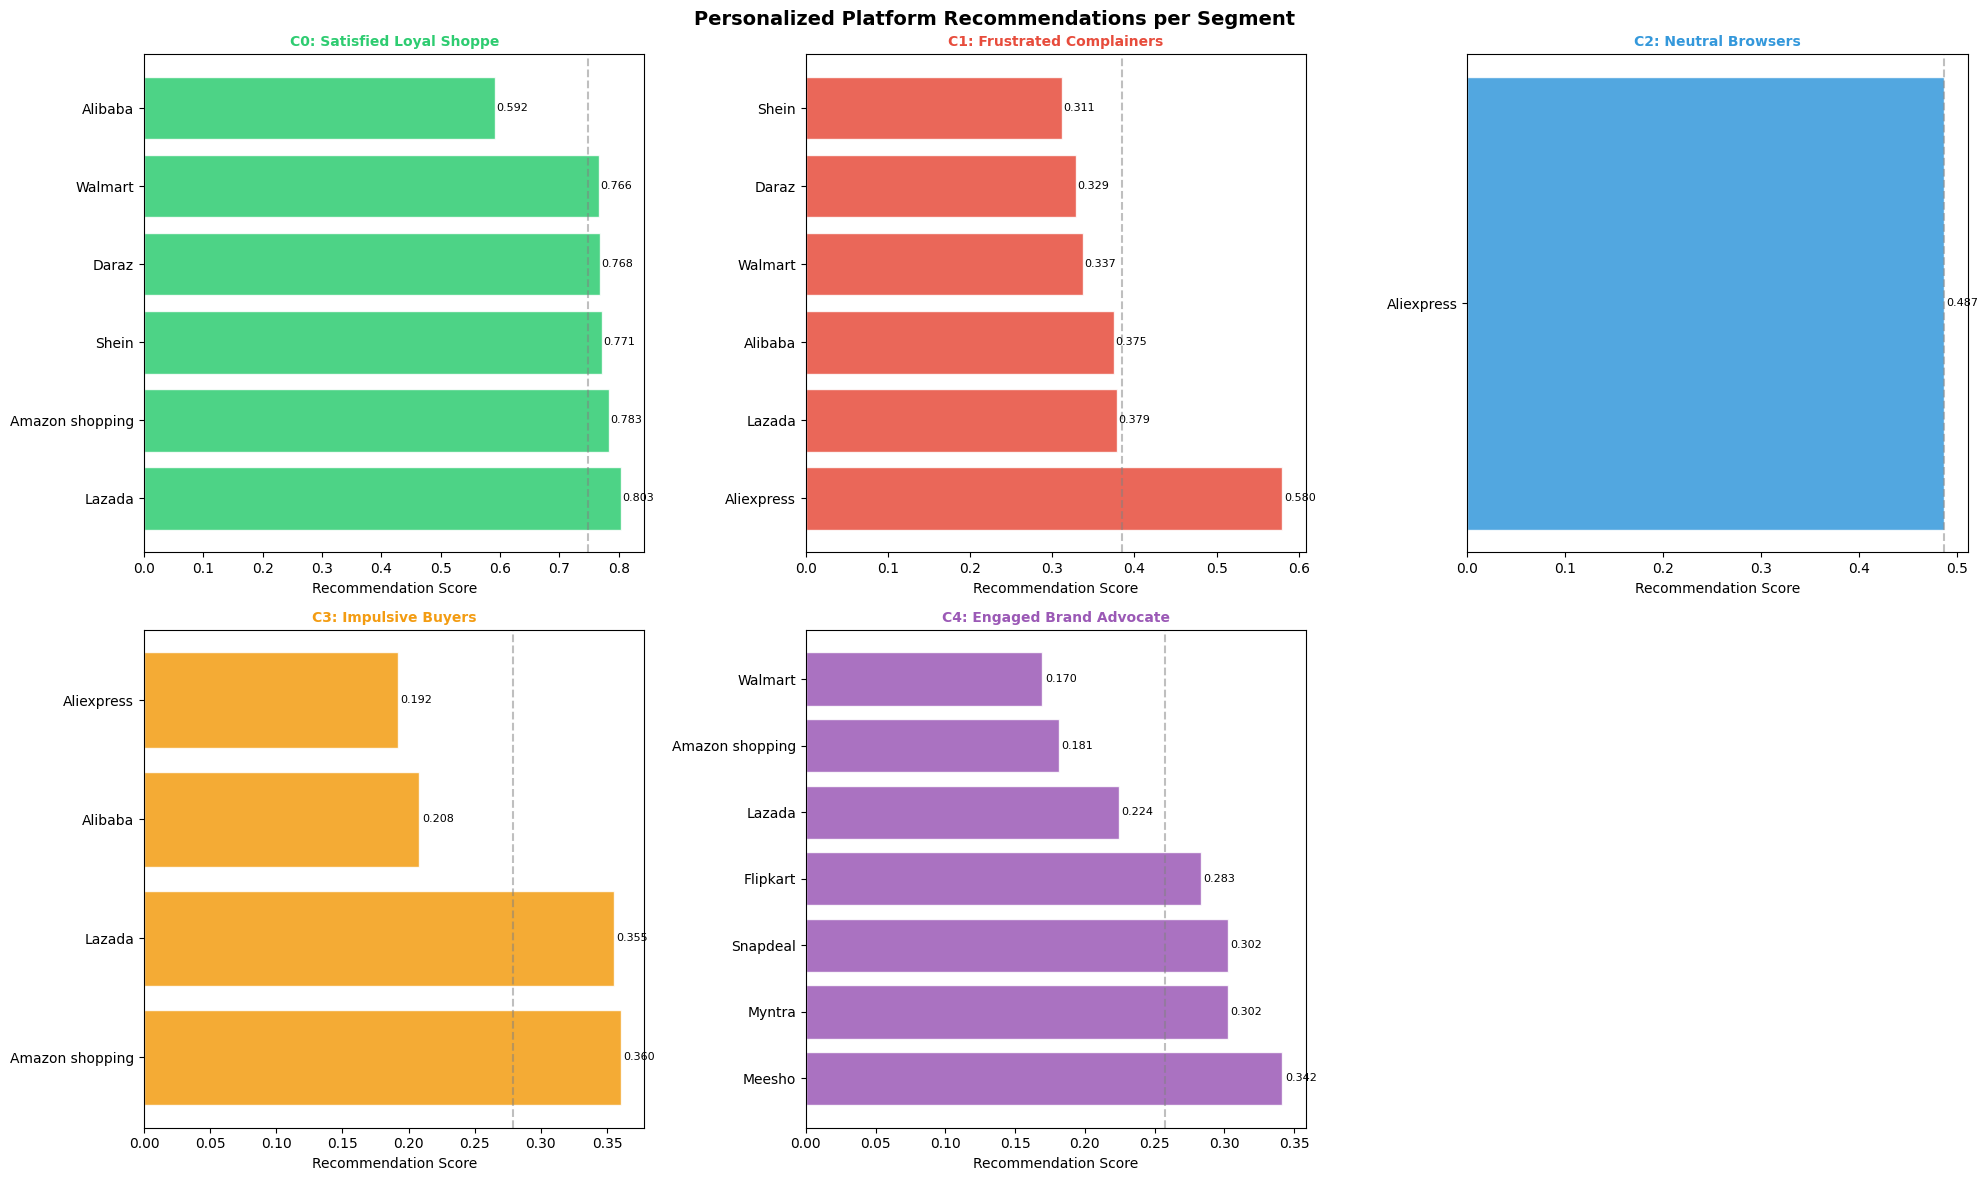

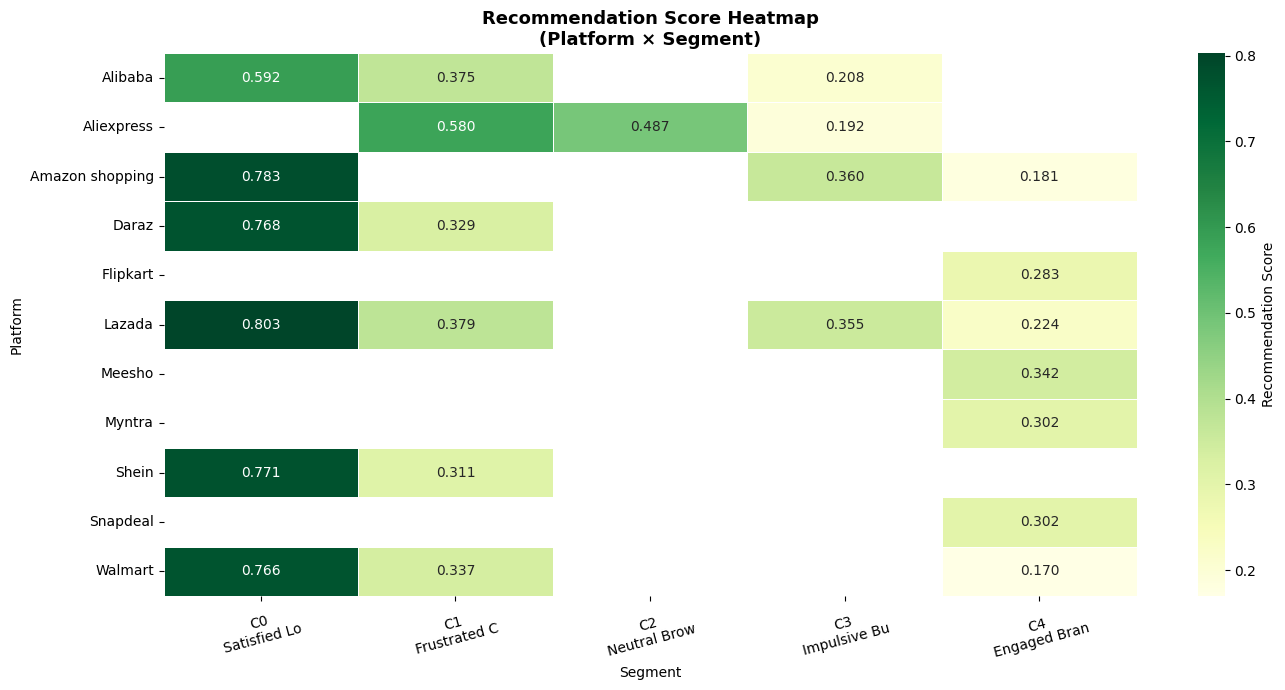

✅ Recommendation visualizations saved


In [5]:
log.info('Visualizing recommendations...')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Personalized Platform Recommendations per Segment',
             fontweight='bold', fontsize=14)

for k in range(CFG['n_segments']):
    ax  = axes[k // 3][k % 3] if CFG['n_segments'] > 3 else axes[k]
    ax  = axes[k // 3, k % 3]

    seg_data = platform_segment_stats[
        platform_segment_stats['final_cluster'] == k
    ].sort_values('rec_score', ascending=False)

    short = seg_data['appName'].str.replace(
        ' Online Shopping App', ''
    ).str.replace(' online shopping & selling', '')\
     .str.replace(' - Online Shopping', '')

    bars = ax.barh(
        short, seg_data['rec_score'],
        color=SEGMENT_COLORS[k], edgecolor='white', alpha=0.85
    )
    ax.set_title(f'C{k}: {SEGMENT_NAMES[k][:22]}',
                 fontweight='bold', fontsize=10,
                 color=SEGMENT_COLORS[k])
    ax.set_xlabel('Recommendation Score')
    ax.axvline(seg_data['rec_score'].mean(), color='gray',
               linestyle='--', alpha=0.5, label='Mean')

    for bar, v in zip(bars, seg_data['rec_score']):
        ax.text(v + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=8)

# ── Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / '08_platform_recommendations.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Heatmap: rec_score per platform × segment
pivot = platform_segment_stats.pivot(
    index='appName', columns='final_cluster', values='rec_score'
)
pivot.index = pivot.index.str.replace(
    ' Online Shopping App', ''
).str.replace(' online shopping & selling', '')\
 .str.replace(' - Online Shopping', '')
pivot.columns = [f'C{k}\n{SEGMENT_NAMES[k][:12]}' for k in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot, annot=True, fmt='.3f',
    cmap='YlGn', linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Recommendation Score'},
    ax=ax
)
ax.set_title('Recommendation Score Heatmap\n(Platform × Segment)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Segment')
ax.set_ylabel('Platform')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / '08_rec_score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Recommendation visualizations saved')

#  User-Level Prediction & Recommendation

In [6]:
log.info('Building user-level recommendation engine...')

# ── Predict segment + sentiment for all users
FEATURE_COLS_AVAIL = [f for f in FEATURE_COLS if f in df.columns]
df_model = df[FEATURE_COLS_AVAIL].fillna(0)
X_all    = scaler.transform(df_model.values)

X_tensor = torch.FloatTensor(X_all).to(DEVICE)
model.eval()

all_seg_preds  = []
all_sent_preds = []
all_seg_probs  = []

batch_size = 1024
with torch.no_grad():
    for i in range(0, len(X_tensor), batch_size):
        batch = X_tensor[i:i+batch_size]
        seg_logits, sent_logits = model(batch)
        all_seg_preds.extend(seg_logits.argmax(1).cpu().numpy())
        all_sent_preds.extend(sent_logits.argmax(1).cpu().numpy())
        all_seg_probs.extend(torch.softmax(seg_logits, dim=1).cpu().numpy())

df['pred_segment']   = all_seg_preds
df['pred_sentiment'] = [SENTIMENT_NAMES[s] for s in all_sent_preds]
df['pred_seg_name']  = df['pred_segment'].map(SEGMENT_NAMES)
df['pred_confidence'] = [max(p) for p in all_seg_probs]

print(f'✅ Predictions complete for {len(df):,} users')
print(f'\n── Predicted segment distribution ──')
for k, name in SEGMENT_NAMES.items():
    n   = (df['pred_segment'] == k).sum()
    pct = n / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'   {k} | {name:<30} | {n:>6,} ({pct:4.1f}%)  {bar}')

print(f'\n── Predicted sentiment distribution ──')
for sent, n in df['pred_sentiment'].value_counts().items():
    pct = n / len(df) * 100
    print(f'   {sent:<10} : {n:>6,} ({pct:4.1f}%)')

# ── Generate recommendations for each user
def recommend_for_user(row, top_n=3):
    cluster_id = int(row['pred_segment'])
    sentiment  = row['pred_sentiment']
    recs       = get_recommendations(cluster_id, sentiment, top_n)
    return [r for r in recs['appName'].values]

print('\n── Generating recommendations for all users ──')
df['recommendations'] = df.apply(
    lambda row: recommend_for_user(row, CFG['top_n']), axis=1
)
df['top_recommendation'] = df['recommendations'].apply(lambda x: x[0] if x else None)

print(f'✅ Recommendations generated')
print(f'\n── Top recommendation distribution ──')
for plat, n in df['top_recommendation'].value_counts().items():
    pct = n / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f'   {plat:<35} : {n:>6,} ({pct:4.1f}%)  {bar}')

# ── Sample recommendations
print(f'\n── Sample recommendations (5 users) ──')
sample_cols = ['final_cluster','segment_name','pred_sentiment',
               'pred_confidence','top_recommendation','recommendations']
sample_cols = [c for c in sample_cols if c in df.columns]
print(df[sample_cols].sample(5, random_state=SEED).to_string(index=False))

2026-04-25 21:26:32,924 | INFO | Building user-level recommendation engine...


✅ Predictions complete for 99,999 users

── Predicted segment distribution ──
   0 | Satisfied Loyal Shoppers       | 19,340 (19.3%)  █████████
   1 | Frustrated Complainers         | 16,690 (16.7%)  ████████
   2 | Neutral Browsers               | 17,469 (17.5%)  ████████
   3 | Impulsive Buyers               | 31,075 (31.1%)  ███████████████
   4 | Engaged Brand Advocates        | 15,425 (15.4%)  ███████

── Predicted sentiment distribution ──
   neutral    : 36,377 (36.4%)
   positive   : 33,009 (33.0%)
   negative   : 30,613 (30.6%)

── Generating recommendations for all users ──
✅ Recommendations generated

── Top recommendation distribution ──
   Aliexpress                          : 34,159 (34.2%)  ███████████
   Amazon shopping                     : 31,075 (31.1%)  ██████████
   Lazada                              : 19,340 (19.3%)  ██████
   Meesho                              : 15,425 (15.4%)  █████

── Sample recommendations (5 users) ──
 final_cluster             segment_nam

# Recommendation Analysis Plots

2026-04-25 21:28:26,822 | INFO | Plotting recommendation analysis...


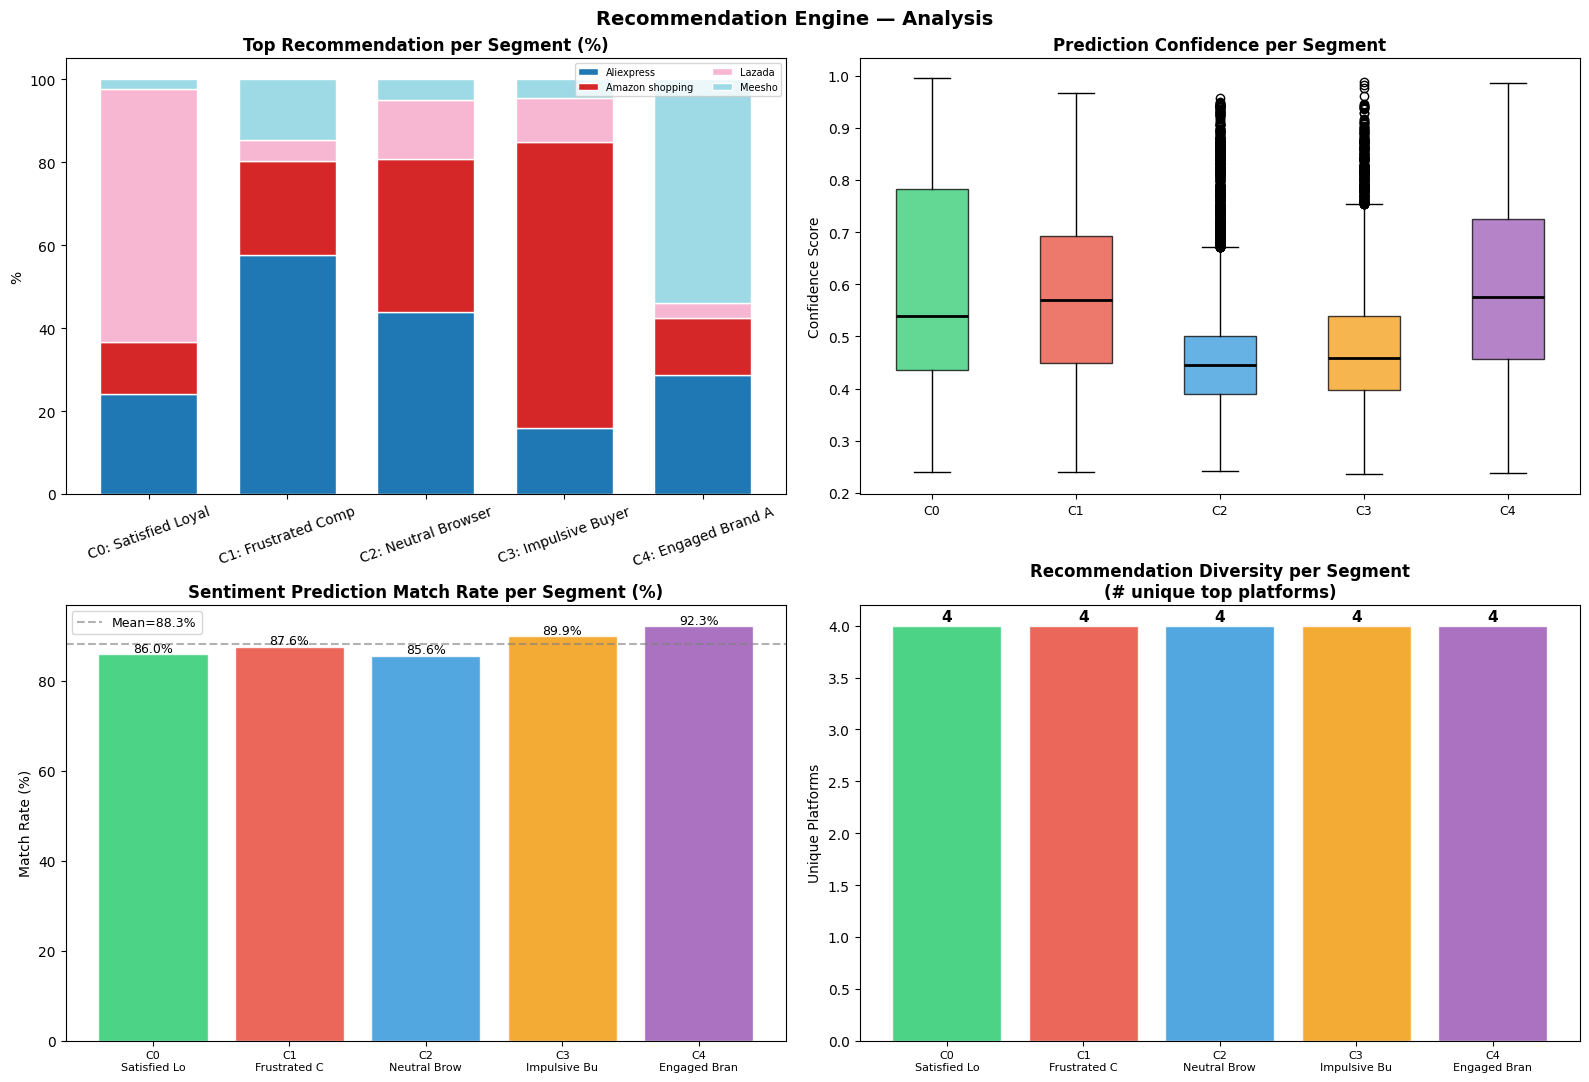

In [7]:
log.info('Plotting recommendation analysis...')

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Recommendation Engine — Analysis',
             fontweight='bold', fontsize=14)

# ── 1. Top recommendation per segment
rec_seg = df.groupby(['final_cluster','top_recommendation']).size().unstack(fill_value=0)
rec_seg_pct = rec_seg.div(rec_seg.sum(axis=1), axis=0) * 100
rec_seg_pct.index = [f'C{k}: {SEGMENT_NAMES[k][:15]}' for k in rec_seg_pct.index]
rec_seg_pct.plot(
    kind='bar', stacked=True, ax=axes[0,0],
    colormap='tab20', edgecolor='white', width=0.7
)
axes[0,0].set_title('Top Recommendation per Segment (%)', fontweight='bold')
axes[0,0].set_ylabel('%')
axes[0,0].tick_params(axis='x', rotation=20)
axes[0,0].legend(fontsize=7, loc='upper right',
                 bbox_to_anchor=(1.0, 1.0), ncol=2)

# ── 2. Prediction confidence per segment
conf_data = [
    df[df['final_cluster'] == k]['pred_confidence'].values
    for k in range(CFG['n_segments'])
]
bp = axes[0,1].boxplot(
    conf_data, patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, k in zip(bp['boxes'], range(CFG['n_segments'])):
    patch.set_facecolor(SEGMENT_COLORS[k])
    patch.set_alpha(0.75)
axes[0,1].set_xticklabels([f'C{k}' for k in range(CFG['n_segments'])], fontsize=9)
axes[0,1].set_title('Prediction Confidence per Segment', fontweight='bold')
axes[0,1].set_ylabel('Confidence Score')

# ── 3. Predicted vs actual sentiment match
df['sent_match'] = df['pred_sentiment'] == df['sentiment']
match_by_seg = df.groupby('final_cluster')['sent_match'].mean() * 100
axes[1,0].bar(
    range(CFG['n_segments']), match_by_seg.values,
    color=[SEGMENT_COLORS[k] for k in range(CFG['n_segments'])],
    edgecolor='white', alpha=0.85
)
axes[1,0].axhline(match_by_seg.mean(), color='gray',
                   linestyle='--', alpha=0.6,
                   label=f'Mean={match_by_seg.mean():.1f}%')
axes[1,0].set_xticks(range(CFG['n_segments']))
axes[1,0].set_xticklabels(
    [f'C{k}\n{SEGMENT_NAMES[k][:12]}' for k in range(CFG['n_segments'])],
    fontsize=8
)
axes[1,0].set_title('Sentiment Prediction Match Rate per Segment (%)',
                     fontweight='bold')
axes[1,0].set_ylabel('Match Rate (%)')
axes[1,0].legend(fontsize=9)
for i, v in enumerate(match_by_seg.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# ── 4. Recommendation diversity per segment
rec_diversity = df.groupby('final_cluster')['top_recommendation'].nunique()
axes[1,1].bar(
    range(CFG['n_segments']), rec_diversity.values,
    color=[SEGMENT_COLORS[k] for k in range(CFG['n_segments'])],
    edgecolor='white', alpha=0.85
)
axes[1,1].set_xticks(range(CFG['n_segments']))
axes[1,1].set_xticklabels(
    [f'C{k}\n{SEGMENT_NAMES[k][:12]}' for k in range(CFG['n_segments'])],
    fontsize=8
)
axes[1,1].set_title('Recommendation Diversity per Segment\n(# unique top platforms)',
                     fontweight='bold')
axes[1,1].set_ylabel('Unique Platforms')
for i, v in enumerate(rec_diversity.values):
    axes[1,1].text(i, v + 0.05, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '08_recommendation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# MLflow Logging & Final Save

In [8]:
log.info('Logging to MLflow...')

mlflow.set_tracking_uri(str(LOG_DIR))
mlflow.set_experiment(CFG['experiment_name'])

with mlflow.start_run(run_name=CFG['run_name']) as run:
    RUN_ID = run.info.run_id

    # ── Parameters
    mlflow.log_params({
        'top_n'          : CFG['top_n'],
        'n_segments'     : CFG['n_segments'],
        'n_platforms'    : df['appName'].nunique(),
        'total_users'    : len(df),
        'scoring_weights': '0.35_pos+0.25_score+0.20_eng+0.10_conf+0.10_frust',
    })

    # ── Metrics
    mlflow.log_metrics({
        'avg_pred_confidence'  : round(df['pred_confidence'].mean(), 4),
        'sentiment_match_rate' : round(df['sent_match'].mean() * 100, 4),
        'rec_coverage'         : round(df['top_recommendation'].nunique() /
                                       df['appName'].nunique() * 100, 4),
    })

    # ── Per-segment metrics
    for k in range(CFG['n_segments']):
        mask = df['final_cluster'] == k
        mlflow.log_metrics({
            f'seg{k}_avg_confidence'  : round(df[mask]['pred_confidence'].mean(), 4),
            f'seg{k}_sentiment_match' : round(df[mask]['sent_match'].mean() * 100, 4),
        })

    # ── Figures
    for fig_file in FIG_DIR.glob('08_*.png'):
        mlflow.log_artifact(str(fig_file), artifact_path='figures')

    # ── Save recommendations JSON
    mlflow.log_dict(recommendations, 'segment_recommendations.json')

print(f'✅ MLflow Run ID: {RUN_ID}')

# ── Save outputs
rec_output = df[[
    'appName', 'sentiment', 'score',
    'final_cluster', 'segment_name',
    'pred_segment', 'pred_seg_name',
    'pred_sentiment', 'pred_confidence',
    'top_recommendation',
]].copy()
rec_output['recommendations'] = df['recommendations'].apply(lambda x: ', '.join(x))
rec_output.to_csv(OUT_DIR / 'user_recommendations.csv', index=False)

with open(OUT_DIR / 'segment_recommendations.json', 'w') as f:
    json.dump(recommendations, f, indent=2, default=str)

platform_segment_stats.to_csv(OUT_DIR / 'platform_scores.csv', index=False)

print('\n✅ Files saved:')
print(f'   user_recommendations.csv')
print(f'   segment_recommendations.json')
print(f'   platform_scores.csv')

print('\n' + '=' * 55)
print('  nb-08 Recommendation Engine COMPLETE')
print('=' * 55)
print(f'  Total users scored    : {len(df):,}')
print(f'  Avg confidence        : {df["pred_confidence"].mean():.4f}')
print(f'  Sentiment match rate  : {df["sent_match"].mean()*100:.2f}%')
print(f'  Platforms covered     : {df["top_recommendation"].nunique()}')
print(f'  MLflow Run ID         : {RUN_ID}')
print('=' * 55)


2026-04-25 21:28:28,319 | INFO | Logging to MLflow...
2026/04/25 21:28:28 INFO mlflow.tracking.fluent: Experiment with name '06_Recommendation_Engine' does not exist. Creating a new experiment.


✅ MLflow Run ID: a62aed5efefe48af92ecf50cd73decda

✅ Files saved:
   user_recommendations.csv
   segment_recommendations.json
   platform_scores.csv

  nb-08 Recommendation Engine COMPLETE
  Total users scored    : 99,999
  Avg confidence        : 0.5385
  Sentiment match rate  : 88.22%
  Platforms covered     : 4
  MLflow Run ID         : a62aed5efefe48af92ecf50cd73decda
